In [1]:
import numpy as numpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec


In [2]:
data = pd.read_csv('creditcard.csv')
print(data.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [3]:
print(data.describe())


                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15   
std    1.380247e+00  1.332271e+00  1.23709

In [ ]:
fraud = data[data['Class'] == 1]
valid = data[data['Class'] == 0]    
outlier_fraction = len(fraud)/float(len(valid))
print(f'{outlier_fraction*100:.3f}%')
#highly imbalanced dataset

0.173%


In [6]:
print(f'fraud cases: {len(fraud)}')
print(f'valid cases: {len(valid)}')

fraud cases: 492
valid cases: 284315


In [13]:
print(fraud.Amount.describe())

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


In [ ]:
print(valid.Amount.describe())
#fraud amount has higher amounts as compared to valid transactions

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64


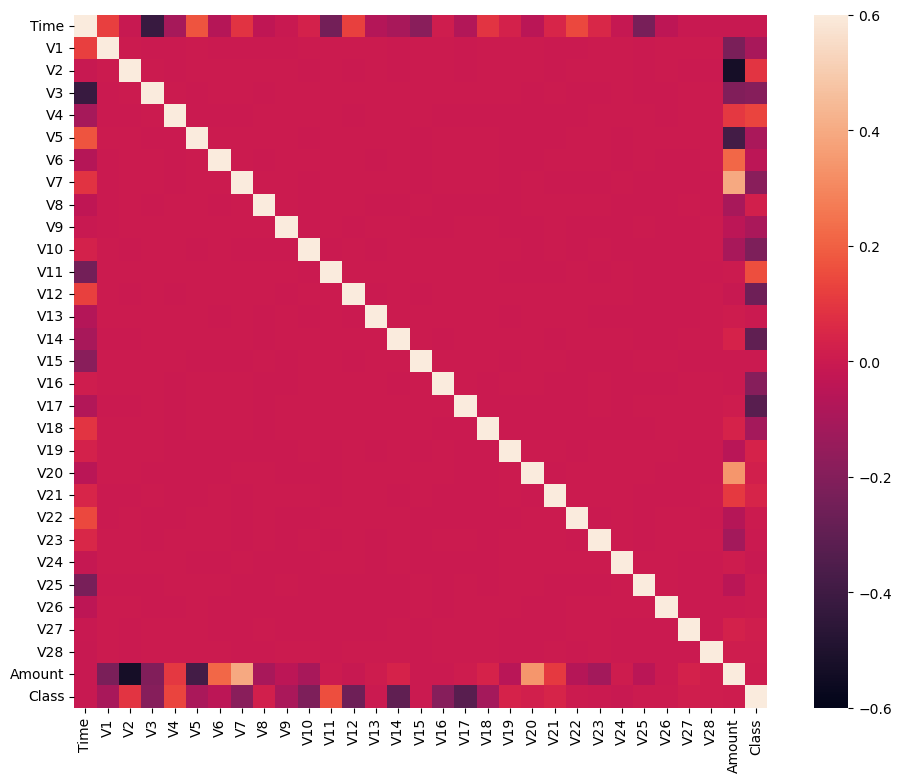

In [26]:
corrmat = data.corr()
fig = plt.figure(figsize = (12,9)) 
sns.heatmap(corrmat,vmin = -0.6, vmax=.6, square=True) 
plt.show()


In [ ]:
# more uncorrelated features include V2, v13, v15, 
#correlated with each other high values only : 

In [42]:
clean1 = data.drop(['Amount', 'V28','V2','V13','V15' ,'V27', 'V26', 'V25', 'V24', 'V23', 'V22', 'V21', 'V20', 'V19'], axis = 1)
clean1.head()

,Time,V1,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V14,V16,V17,V18,Class
0,0.0,-1.359807,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.311169,-0.470401,0.207971,0.025791,0
1,0.0,1.191857,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,-0.143772,0.463917,-0.114805,-0.183361,0
2,1.0,-1.358354,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,-0.165946,-2.890083,1.109969,-0.121359,0
3,1.0,-0.966272,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,-0.287924,-1.059647,-0.684093,1.965775,0
4,2.0,-1.158233,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,-1.119670,-0.451449,-0.237033,-0.038195,0


<Axes: xlabel='Class'>

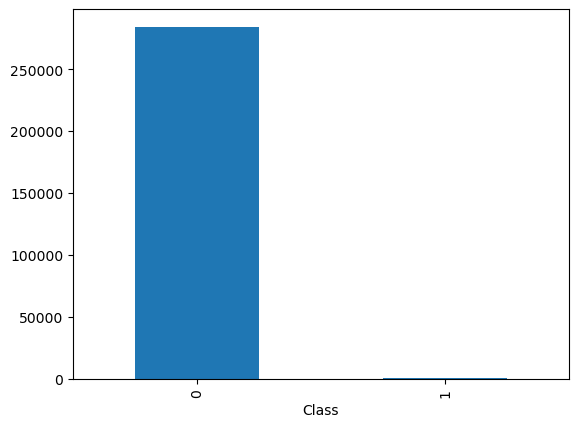

In [63]:
classes = clean1['Class'].value_counts()
classes.plot(kind = 'bar')

In [74]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

X = clean1.drop(['Class'], axis=1)
Y = clean1['Class']

# Optional: keep as DataFrame/Series
xtrain, xtest, ytrain, ytest = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

smote = SMOTE(sampling_strategy='auto', random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(xtrain, ytrain)

print("Before SMOTE:", ytrain.value_counts())
print("After SMOTE:", y_train_res.value_counts())


Before SMOTE: Class
0    227451
1       394
Name: count, dtype: int64
After SMOTE: Class
0    227451
1    227451
Name: count, dtype: int64


In [75]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()    
model.fit(xtrain, ytrain)
ypred = model.predict(xtest)

In [77]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score, precision_score, recall_score,matthews_corrcoef
print(confusion_matrix(ytest, ypred))
print(f'F1 Score: {f1_score(ytest, ypred)}')
print(f'Precision Score: {precision_score(ytest, ypred)}')
print(f'Recall Score: {recall_score(ytest, ypred)}')
mcc = matthews_corrcoef(ytest, ypred)
print(mcc)

[[56861     3]
 [   17    81]]
F1 Score: 0.8901098901098901
Precision Score: 0.9642857142857143
Recall Score: 0.826530612244898
0.8925882401403168
